In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/5/PBMC5_clustering.h5ad"

adata = sc.read(dir)

In [3]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 78900 × 20061
  var:	'n_cells'
  2 modalities
    rna:	78876 x 20053
      obs:	'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'dendrogram_leiden_res1', 'final_anno_colors', 'final_broad_colors', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'manual_celltype_annotation_1_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	24 x 8
      obs:	'diagnosis', 'sample'
      var:	'n_cells'

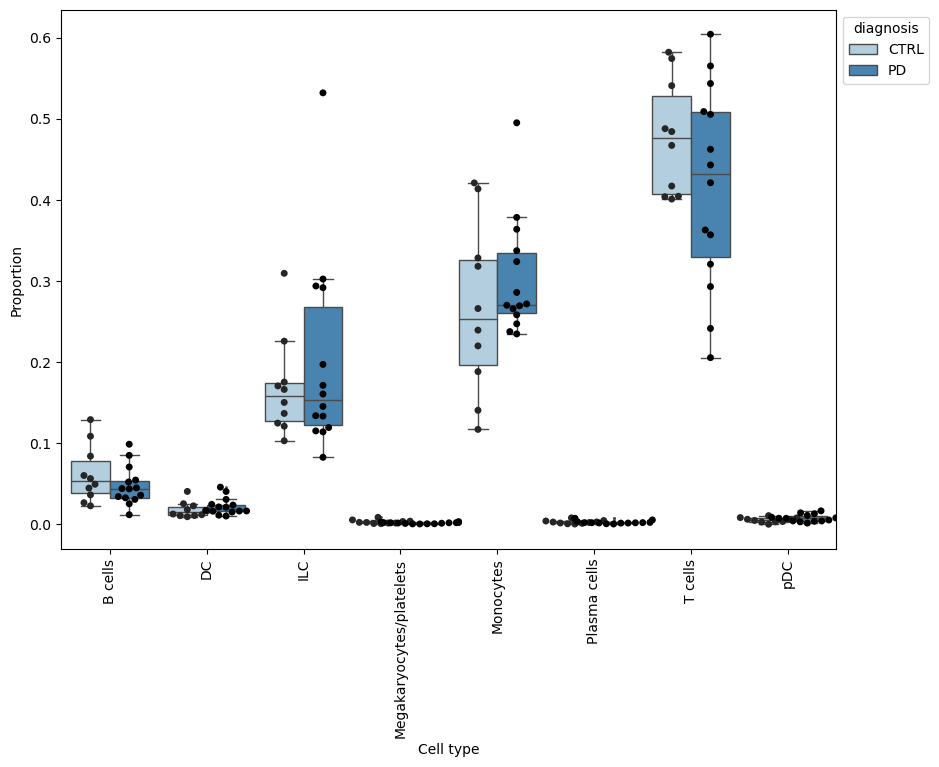

In [4]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"color": "red"},
)
plt.show()

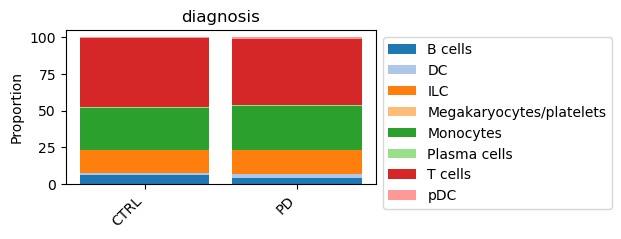

In [5]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [6]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'PD'], dtype='object')

In [7]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:22<00:00, 132.91it/s, 127 steps of size 2.80e-02. acc. prob=0.86]


In [8]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.498,0.181,0.147,0.5158,180.432256,0.0
DC,0.0,-0.305,0.417,0.132,0.4829,82.628561,0.0
ILC,0.0,-0.220,0.287,0.084,0.4082,556.883129,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,23.768363,0.0
Monocytes,0.0,-0.098,0.376,0.108,0.4852,866.407538,0.0
Plasma cells,0.0,-0.367,0.431,0.144,0.4761,25.390000,0.0
T cells,0.0,-0.448,0.015,0.145,0.7611,1512.252281,0.0
pDC,0.0,-0.268,0.524,0.147,0.4802,38.758706,0.0


In [9]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). At FDR 0.05

In [10]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
credible = sccoda_model.credible_effects(sccoda_data, modality_key="coda")
credible

Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 ILC                         False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 Plasma cells                False
                 T cells                     False
                 pDC                         False
Name: Final Parameter, dtype: bool

In [11]:
# identify significant cell types for downstream analyses

# dictionary for stars
significance_mapping = {
    celltype: "*"
    for (effect, celltype), is_sig in credible.items()
    if is_sig
}

In [12]:
significance_mapping

{}

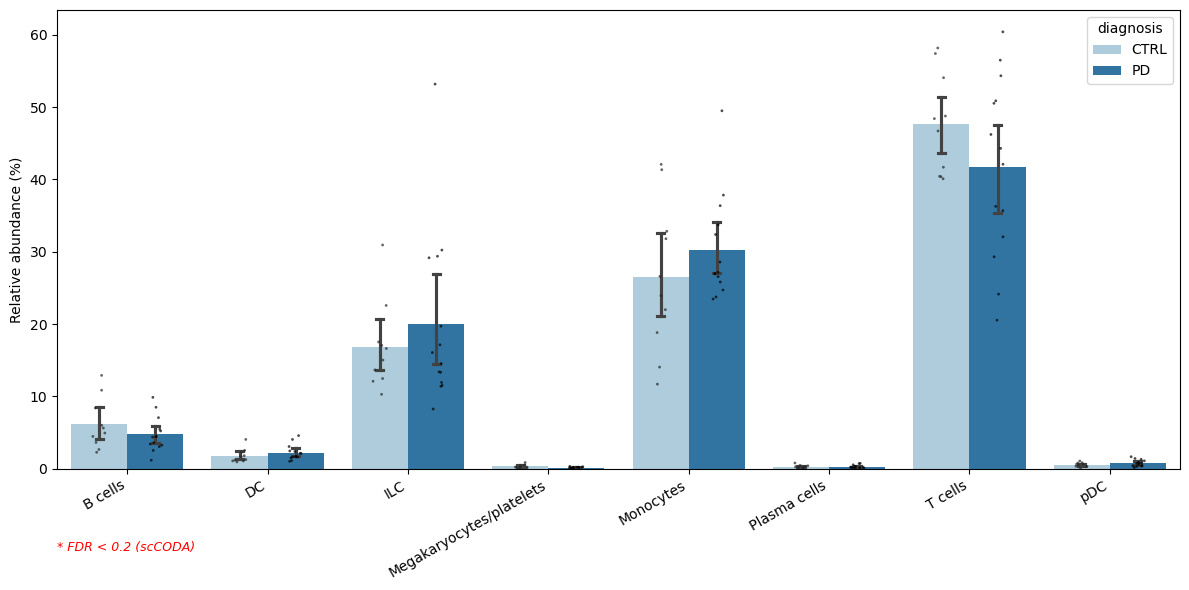

In [13]:
# plot relative abundances of cell types across the two conditions
coda = sccoda_data["coda"]

# Build relative-abundance long-format dataframe in one chain
plot_df = (
    pd.DataFrame(coda.X, index=coda.obs_names, columns=coda.var_names)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
    .assign(diagnosis=coda.obs["diagnosis"].values)
    .reset_index(names="sample")
    .melt(id_vars=["sample", "diagnosis"], var_name="cell_type", value_name="rel_abundance")
)

cell_types = plot_df["cell_type"].unique().tolist()

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    errorbar=("ci", 95), capsize=0.1, palette="Paired", ax=ax
)
sns.stripplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    dodge=True, color="black", alpha=0.7, size=2, legend=False, ax=ax
)

# Significance annotations 
PAD      = 1.2   # gap between bar top and bracket
TXT_PAD  = 0.4   # gap between bracket and asterisk

for ct, label in significance_mapping.items():
    x   = cell_types.index(ct)
    top = plot_df.loc[plot_df["cell_type"] == ct, "rel_abundance"].max()
    y_bracket = top + PAD
    y_text    = y_bracket + TXT_PAD

    # horizontal bracket line
    ax.plot(
        [x - 0.2, x + 0.2], [y_bracket, y_bracket],
        color="black", linewidth=1.2, solid_capstyle="round"
    )
    # asterisk with bold weight + contrasting background box
    ax.text(
        x, y_text, label,
        ha="center", va="bottom", fontsize=16, fontweight="bold", color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    )

ax.annotate(
    "* FDR < 0.2 (scCODA)",
    xy=(0, -0.18), xycoords="axes fraction",
    fontsize=9, color="red", style="italic"
)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



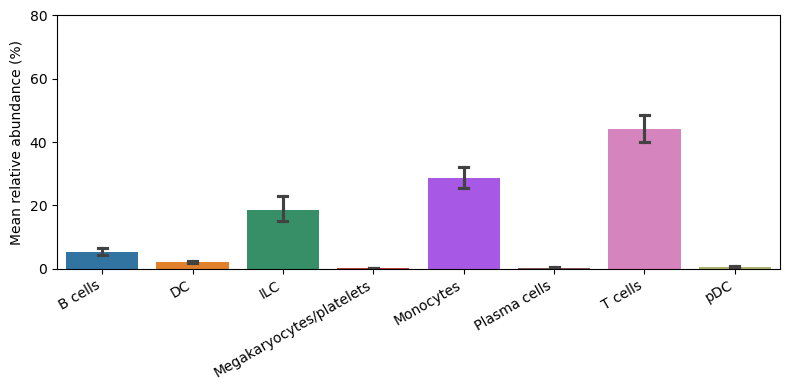

In [26]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  # was "cell_type" — column doesn't exist yet
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

In [15]:
# recalculate relative abundance just for controls samples

ctrl_data = adata[adata.obs["diagnosis"] == "CTRL"]

ctrl_plot_df = (
    ctrl_data.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

ctrl_plot_df

,sample,celltypist_cell_label_coarse,count,rel_abundance
0,CTRL1,B cells,238,5.626478
1,CTRL1,DC,71,1.678487
2,CTRL1,ILC,435,10.283688
3,CTRL1,Megakaryocytes/platelets,6,0.141844
4,CTRL1,Monocytes,1749,41.347518
...,...,...,...,...
75,CTRL10,Megakaryocytes/platelets,6,0.334448
76,CTRL10,Monocytes,252,14.046823
77,CTRL10,Plasma cells,1,0.055741
78,CTRL10,T cells,875,48.773690


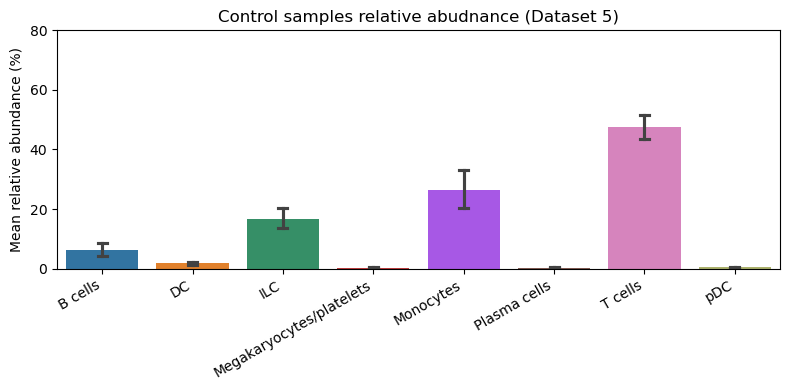

In [25]:
# plot just the control samples:

plt.figure(figsize=(8, 4))
sns.barplot(
    data=ctrl_plot_df,
    x="celltypist_cell_label_coarse",
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.title("Control samples relative abudnance (Dataset 5)")
plt.tight_layout()
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.show()


In [ ]:
# check that the control relative abdunaces values add up to 100% for each sample

ctrl_plot_df.groupby("sample")["rel_abundance"].sum()

In [ ]:
# Compare numerical differences between all samples and control-only samples

# Calculate mean relative abundance by cell type
all_samples_mean = plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()
ctrl_only_mean = ctrl_plot_df.groupby("celltypist_cell_label_coarse")["rel_abundance"].mean()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "All samples (%)": all_samples_mean,
    "Control only (%)": ctrl_only_mean,
})
comparison_df["Difference (%)"] = comparison_df["All samples (%)"] - comparison_df["Control only (%)"]
comparison_df = comparison_df.sort_values("Difference (%)", ascending=False)

print("Cell type composition comparison:\n")
print(comparison_df.round(2))


In [16]:
# redo composition analysis with fine annotations 

sccoda_model2 = pt.tl.Sccoda()
sccoda_data2 = sccoda_model2.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_fine",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data2

MuData object with n_obs × n_vars = 78900 × 20071
  var:	'n_cells'
  2 modalities
    rna:	78876 x 20053
      obs:	'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'dendrogram_leiden_res1', 'final_anno_colors', 'final_broad_colors', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'manual_celltype_annotation_1_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	24 x 18
      obs:	'diagnosis', 'sample'
      var:	'n_cells'

In [17]:
# run scCODA model
sccoda_data2 = sccoda_model2.prepare(
    sccoda_data2,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model2.run_nuts(sccoda_data2, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:09<00:00, 159.07it/s, 63 steps of size 6.20e-02. acc. prob=0.70]


In [18]:
sccoda_data2["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_fine,,,,,,,
Age-associated B cells,0.0,0.000,0.000,0.000,0.0000,17.554403,0.0
CD16+ NK cells,0.0,-0.113,0.244,0.072,0.4898,579.001338,0.0
Classical monocytes,0.0,-0.049,0.332,0.108,0.6369,672.703581,0.0
DC1,0.0,-0.262,0.283,0.098,0.5031,16.107819,0.0
DC2,0.0,-0.186,0.323,0.096,0.5007,77.424618,0.0
MAIT cells,0.0,-0.322,0.200,0.097,0.5105,43.567209,0.0
Megakaryocytes/platelets,0.0,-0.316,0.232,0.104,0.5047,20.974445,0.0
Memory B cells,0.0,-0.279,0.241,0.093,0.4885,52.841919,0.0
Naive B cells,0.0,-0.314,0.159,0.091,0.5015,130.883130,0.0


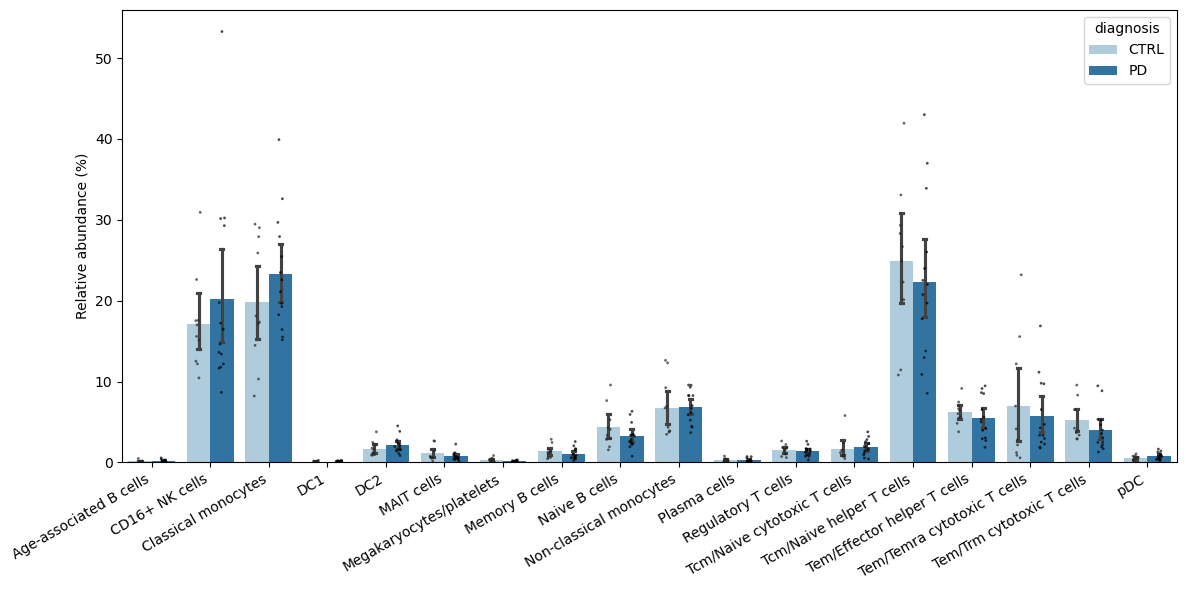

In [19]:
# plot relative abundances of cell types across the two conditions

coda = sccoda_data2["coda"]

# counts -> dataframe
df = pd.DataFrame(
    coda.X,
    index=coda.obs_names,
    columns=coda.var_names
)

# relative abundances
df = df.div(df.sum(axis=1), axis=0) * 100

# add group label
df["diagnosis"] = coda.obs["diagnosis"].values

# long format
plot_df = df.reset_index(names="sample").melt(
    id_vars=["sample", "diagnosis"],
    var_name="cell_type",
    value_name="rel_abundance"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    errorbar=("ci", 95),
    capsize = 0.1,
    palette= "Paired"
)
sns.stripplot(
    data=plot_df,
    x="cell_type",
    y="rel_abundance",
    hue="diagnosis",
    dodge=True,
    color="black",
    alpha=0.7,
    size=2,
    legend = False
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [20]:
sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC1                            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Plasma cells                   False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                 

In [21]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model2.set_fdr(sccoda_data2, 0.2)
credible = sccoda_model2.credible_effects(sccoda_data2, modality_key="coda")
credible


Covariate        Cell Type                  
diagnosis[T.PD]  Age-associated B cells         False
                 CD16+ NK cells                 False
                 Classical monocytes            False
                 DC1                            False
                 DC2                            False
                 MAIT cells                     False
                 Megakaryocytes/platelets       False
                 Memory B cells                 False
                 Naive B cells                  False
                 Non-classical monocytes        False
                 Plasma cells                   False
                 Regulatory T cells             False
                 Tcm/Naive cytotoxic T cells    False
                 Tcm/Naive helper T cells       False
                 Tem/Effector helper T cells    False
                 Tem/Temra cytotoxic T cells    False
                 Tem/Trm cytotoxic T cells      False
                 pDC                 

In [22]:
sccoda_model2.set_fdr(sccoda_data2, 0.05)
